# Feature Importance Tutorial

This notebook is a guided introduction to feature importance in streaming classification with CapyMOA.

The tutorial is split into two parts:
- a quick-start MOA workflow you can run top to bottom
- a few optional advanced examples at the end

In the main walkthrough we will:
- create a stream and a `MOAFeatureImportanceClassifier`
- run a simple test-then-train loop
- inspect feature importances and top-ranked features
- plot final and windowed importance values

---

*More information about CapyMOA can be found at* https://www.capymoa.org.

**last update on 08/04/2026**


## 1. Imports

Import the core learner, dataset, evaluator, and plotting helpers used in the quick-start.


In [1]:
from capymoa.classifier import HoeffdingTree
from capymoa.datasets import Electricity
from capymoa.evaluation import ClassificationEvaluator
from capymoa.feature_selection import (
    MOAFeatureImportanceClassifier,
    plot_feature_importance,
    plot_windowed_feature_importance,
)

## 2. Prepare the Stream and Learner

Create the stream, build a `HoeffdingTree`, wrap it with `MOAFeatureImportanceClassifier`, and prepare feature names for plotting.


> Note:
> `MOAFeatureImportanceClassifier` currently supports `HoeffdingTree` learners and subclasses, plus MOA ensembles built from `HoeffdingTree` learners.
> If MOA adds other feature-importance learner families in the future, this wrapper will need refactoring before they work here.
>
> If you want a pure Python implementation instead, skip ahead to the final section on `FeatureImportanceClassifier`.


In [2]:
stream = Electricity()
schema = stream.get_schema()

base_learner = HoeffdingTree(schema=schema, random_seed=1)
learner = MOAFeatureImportanceClassifier(
    schema=schema,
    base_learner=base_learner,
    random_seed=1,
    window_size=100,
)
evaluator = ClassificationEvaluator(schema=schema)

# None means run the full stream
max_instances = None

# Use schema attribute names in original order (excluding target)
header = schema.get_moa_header()
class_index = header.classIndex()
feature_names = [
    str(header.attribute(i).name())
    for i in range(header.numAttributes())
    if i != class_index
]

print("Feature names:", feature_names)

Feature names: ['date', 'day', 'period', 'nswprice', 'nswdemand', 'vicprice', 'vicdemand', 'transfer']


## 3. Train Online

Run a standard test-then-train loop: predict first, update the evaluator, then train on the same instance.


In [3]:
stream.restart()
for i, instance in enumerate(stream):
    if max_instances is not None and i >= max_instances:
        break

    prediction = learner.predict(instance)
    evaluator.update(instance.y_index, prediction)
    learner.train(instance)

print(f"Accuracy: {evaluator.accuracy():.2f}%")

Accuracy: 81.22%


## 4. Inspect the Results

Read the current feature importance values and inspect the most important features.


In [4]:
final_importances = learner.get_feature_importances()
top_k = learner.get_top_k_features(3)

print("Feature importances:", final_importances)
print("Top-3 feature indexes:", top_k)
[(feature_names[i], final_importances[i]) for i in top_k]

Feature importances: [0.5156230349777511, 0.02796222956931545, 0.0, 0.29194504058727344, 0.05011512506207069, 0.04036369706674289, 0.07399087273684632, 0.0]
Top-3 feature indexes: [0, 3, 6]


[('date', 0.5156230349777511),
 ('nswprice', 0.29194504058727344),
 ('vicdemand', 0.07399087273684632)]

## 5. Visualize Feature Importance

Plot both the final importance values and the windowed history collected during training.


/var/folders/6x/x08sn06n48n16fjhcql89bb80000gn/T/ipykernel_97634/3519222578.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.figure.show()


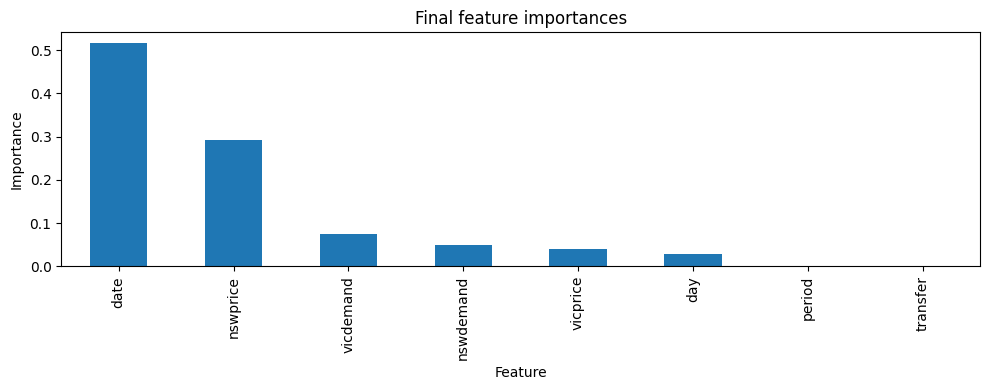

In [5]:
ax = plot_feature_importance(
    final_importances,
    feature_names=feature_names,
    title="Final feature importances",
)
ax.figure.show()

/var/folders/6x/x08sn06n48n16fjhcql89bb80000gn/T/ipykernel_97634/801857445.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.figure.show()


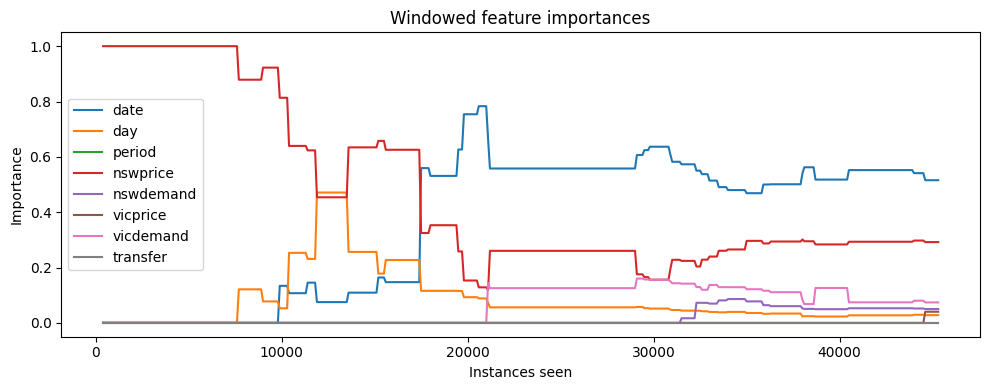

In [6]:
windowed = learner.get_windowed_feature_importances() or []
if len(windowed) == 0:
    print("No windowed importances found. Set window_size to a positive value.")
else:
    ax = plot_windowed_feature_importance(
        windowed_importances=windowed,
        feature_names=feature_names,
        title="Windowed feature importances",
    )
    ax.figure.show()

## 6. Variation: Disable Window History

Set `window_size=None` when you only need the current/final importance values and do not want to store snapshots over time.


In [7]:
# A second learner without window tracking
no_window_learner = MOAFeatureImportanceClassifier(
    schema=schema,
    base_learner=HoeffdingTree(schema=schema, random_seed=1),
    random_seed=1,
    window_size=None,
)

stream.restart()
for i, instance in enumerate(stream):
    if i >= 1000:
        break
    _ = no_window_learner.predict(instance)
    no_window_learner.train(instance)

no_window_importances = no_window_learner.get_feature_importances()
print("Feature importances:", no_window_importances)
print("Windowed importances:", no_window_learner.get_windowed_feature_importances())

Feature importances: [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
Windowed importances: None


## 7. Advanced: Supported `base_learner` Inputs

This section is a short reference for the most common `base_learner` patterns accepted by `MOAFeatureImportanceClassifier`.

You can skip it on a first read if the quick-start example above is all you need.

- `None`: use the default `FeatureImportanceHoeffdingTree`
- a regular `HoeffdingTree` learner: wrap it with `FeatureImportanceHoeffdingTree`
- a HoeffdingTree-based ensemble: fall back to `FeatureImportanceHoeffdingTreeEnsemble`


In [8]:
from capymoa.classifier import AdaptiveRandomForestClassifier


def describe_feature_importance_learner(label, learner):
    moa_name = str(learner.moa_learner.getClass().getSimpleName())
    print(f"{label}: {moa_name}")


constructor_examples = [
    (
        "Default wrapper",
        MOAFeatureImportanceClassifier(schema=schema, random_seed=1),
    ),
    (
        "Single HoeffdingTree learner",
        MOAFeatureImportanceClassifier(
            schema=schema,
            base_learner=HoeffdingTree(schema=schema, random_seed=1),
            random_seed=1,
        ),
    ),
    (
        "HoeffdingTree ensemble fallback",
        MOAFeatureImportanceClassifier(
            schema=schema,
            base_learner=AdaptiveRandomForestClassifier(schema=schema, random_seed=1),
            random_seed=1,
        ),
    ),
]

for label, example in constructor_examples:
    describe_feature_importance_learner(label, example)

Default wrapper: FeatureImportanceHoeffdingTree
Single HoeffdingTree learner: FeatureImportanceHoeffdingTree
HoeffdingTree ensemble fallback: FeatureImportanceHoeffdingTreeEnsemble


The classifier is not an ensemble or does not implement the getSubClassifiers() method. 
The classifier is not an ensemble or does not implement the getSubClassifiers() method. 


## 8. Advanced: Pure Python `FeatureImportanceClassifier`

You can also subclass `FeatureImportanceClassifier` directly for a pure Python method.

In that case you implement:
- `train`
- `predict_proba`
- `get_feature_importances`

If you want windowed snapshots, call `_on_train_complete()` inside `train`.


In [9]:
import numpy as np
from capymoa.feature_selection import FeatureImportanceClassifier


class MyFeatureImportanceClassifier(FeatureImportanceClassifier):
    def __init__(self, schema, random_seed=1, window_size=None):
        super().__init__(
            schema=schema, random_seed=random_seed, window_size=window_size
        )
        self.importances = np.zeros(schema.get_num_attributes(), dtype=float)

    def train(self, instance):
        self.importances += np.abs(instance.x)
        self._on_train_complete()

    def predict_proba(self, instance):
        num_classes = self.schema.get_num_classes()
        return np.ones(num_classes, dtype=float) / num_classes

    def get_feature_importances(self, normalize=True):
        values = self.importances.copy()
        if normalize and values.sum() > 0:
            values = values / values.sum()
        return values.tolist()


my_learner = MyFeatureImportanceClassifier(
    schema=schema,
    random_seed=1,
    window_size=200,
)

stream.restart()
for i, instance in enumerate(stream):
    if i >= 500:
        break
    _ = my_learner.predict(instance)
    my_learner.train(instance)

print("My feature importances:", my_learner.get_feature_importances())
print("My top-3 features:", my_learner.get_top_k_features(3))
print("My window count:", len(my_learner.get_windowed_feature_importances() or []))

My feature importances: [4.5759928239732854e-05, 0.60335052949284, 0.10700814256881178, 0.017887455098169098, 0.08726218981631997, 0.0007601076619737294, 0.09272019955685418, 0.09096561587679161]
My top-3 features: [1, 2, 6]
My window count: 2
